In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
# | Column                       | Meaning                                                                              | Typical Range | Why It Matters                                                                             |
# | ---------------------------- | ------------------------------------------------------------------------------------ | ------------- | ------------------------------------------------------------------------------------------ |
# | **Pregnancies**              | Number of times the patient has been pregnant                                        | 0 to \~17     | More pregnancies can increase diabetes risk due to hormone changes and stress on the body. |
# | **Glucose**                  | Plasma glucose concentration (mg/dL) after 2 hours in an oral glucose tolerance test | 70–200+       | High glucose levels are a key sign of diabetes. One of the most predictive features.       |
# | **BloodPressure**            | Diastolic blood pressure (mm Hg)                                                     | 60–120        | High BP often appears with diabetes and increases complications.                           |
# | **SkinThickness**            | Triceps skin fold thickness (mm)                                                     | 10–99         | Measures body fat percentage. Higher fat levels can indicate insulin resistance.           |
# | **Insulin**                  | 2-hour serum insulin (mu U/mL)                                                       | 15–846        | Insulin helps glucose enter cells. Low or abnormal levels can signal diabetes.             |
# | **BMI**                      | Body Mass Index (weight in kg / height in m²)                                        | 18.5–50+      | A high BMI suggests overweight/obesity — a major diabetes risk factor.                     |
# | **DiabetesPedigreeFunction** | A score that rates genetic/family history of diabetes                                | 0.0–2.5       | Higher values = stronger family history → higher risk.                                     |
# | **Age**                      | Patient’s age (in years)                                                             | 21–81         | Risk of diabetes increases with age, especially over 40.                                   |
# | **Outcome**                  | Diagnosis result (0 = No Diabetes, 1 = Diabetes)                                     | 0 or 1        | This is the label your ML model learns to predict.                                         |


In [4]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# EDA

In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.duplicated().sum()


0

In [10]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

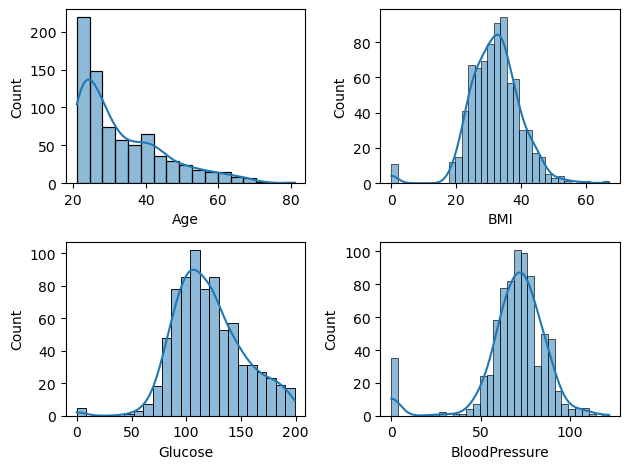

In [12]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('BMI',2)
plotting('Glucose',3)
plotting('BloodPressure',4)

plt.tight_layout()

In [13]:
BMI_mean = df.loc[df['BMI'] !=0,'BMI'].median()
df['BMI'] = df['BMI'].replace(0,BMI_mean)
df['BMI'] = df['BMI'].round(2)

In [14]:
Glucose_mean = df.loc[df['Glucose'] !=0,'Glucose'].median()
df['Glucose'] = df['Glucose'].replace(0,Glucose_mean)
df['Glucose'] = df['Glucose'].round(2)

In [15]:
BloodPressure_mean = df.loc[df['BloodPressure'] !=0,'BloodPressure'].median()
df['BloodPressure'] = df['BloodPressure'].replace(0,BloodPressure_mean)
df['BloodPressure'] = df['BloodPressure'].round(2)

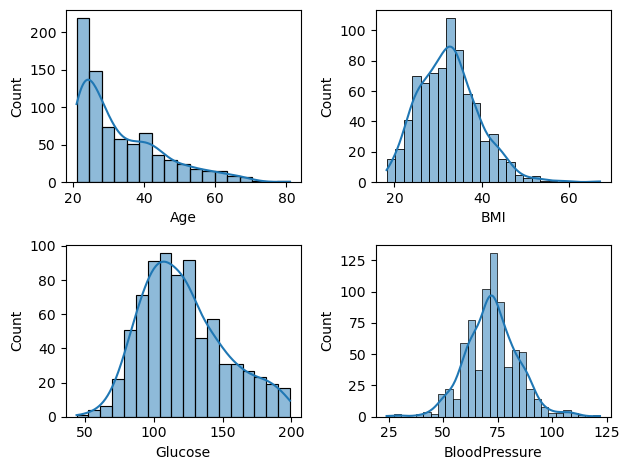

In [16]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('BMI',2)
plotting('Glucose',3)
plotting('BloodPressure',4)

plt.tight_layout()

<Axes: xlabel='Outcome', ylabel='Age'>

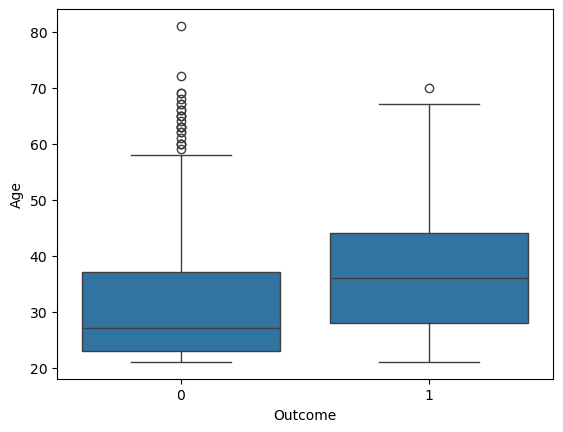

In [17]:
sns.boxplot(x='Outcome', y='Age', data=df)

<Axes: >

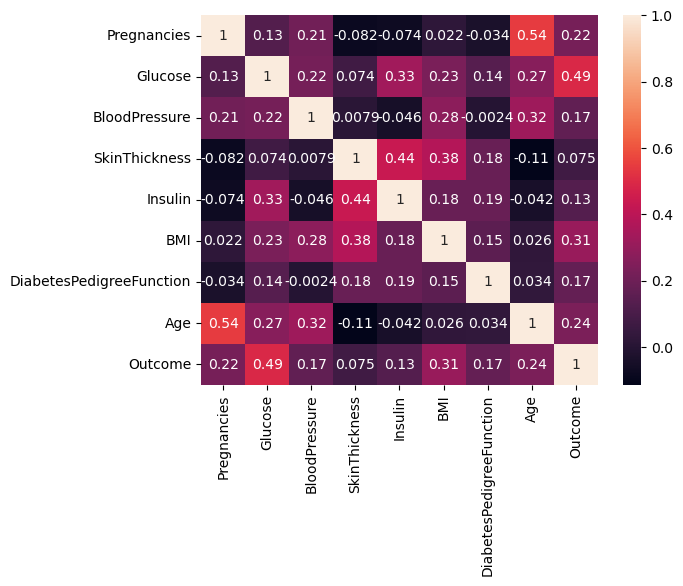

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [19]:
df.drop(['SkinThickness'],axis=1,inplace=True)
# df.drop(['Insulin'],axis=1,inplace=True)
df.drop(['BloodPressure'],axis=1,inplace=True)

In [20]:
# df = df.astype(int)

In [21]:
df

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,0,33.6,0.627,50,1
1,1,85,0,26.6,0.351,31,0
2,8,183,0,23.3,0.672,32,1
3,1,89,94,28.1,0.167,21,0
4,0,137,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,180,32.9,0.171,63,0
764,2,122,0,36.8,0.340,27,0
765,5,121,112,26.2,0.245,30,0
766,1,126,0,30.1,0.349,47,1


In [22]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   Insulin                   768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 42.1 KB


In [23]:
df.columns

Index(['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction',
       'Age', 'Outcome'],
      dtype='object')

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score , classification_report

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [25]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [27]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.fit_transform(X_test)

In [28]:
models = {
    "Logistic Regression" : LogisticRegression() ,
    "KNN" : KNeighborsClassifier() ,
    "Naive Byeas" : GaussianNB() ,
    "Decision Tree" : DecisionTreeClassifier() ,
    "SVM" : SVC()
 }

In [29]:
result = []

In [30]:
for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model' : name, 
        'Accuracy' : round(acc,4),
        "f1 score" : round(f1,4)
    })

In [31]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.7987, 'f1 score': 0.6931},
 {'model': 'KNN', 'Accuracy': 0.6753, 'f1 score': 0.537},
 {'model': 'Naive Byeas', 'Accuracy': 0.7987, 'f1 score': 0.7103},
 {'model': 'Decision Tree', 'Accuracy': 0.6883, 'f1 score': 0.5862},
 {'model': 'SVM', 'Accuracy': 0.7403, 'f1 score': 0.6078}]

In [32]:
model = GaussianNB()
model.fit(x_train_scaled,y_train)
y_pred = model.predict(x_test_scaled)
acc = accuracy_score(y_test,y_pred)

In [33]:
acc

0.7987012987012987

In [71]:
import joblib
joblib.dump(models['Naive Byeas'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')


['columns.pkl']